# W3 fly dislocation — QDB reference run (frozen config)

Engine-native reference run of `BT/signals/cvx_fly_dislocation.py` on the
shipped signal panel `docs/cvxsuite/dislocation_panel.parquet`: PCA-neutral
micro-fly fades of extreme, sign-agreeing kink residuals outside
meeting/convexity zones. The QDB grid is the union of the priced episode
windows.

**FROZEN config (docs/cvxsuite/DESIGN.md §6 "Dislocation" — ONE config, run
AS IS, ugly numbers are the deliverable):** `disl_min_abs_z = 2.0`,
sign_agree required (agreement WITH the fade: `sign_agree == sign(zs)`,
§6a item 4), tags == "clean", `disl_min_edge_bp = 1.0` after 1× cost on the
book's own 63bd clock, `max_hold = 63bd`, exits zero-cross / +2SD
(multiplicative `exit_z_mult = 2.0`), package DV01 $50k, all-in 3-leg round
trip `cost_rt_bp = 2.3` (the §6 2.0–2.6bp band mid) denominated on the
suite-wide belly=+2 ruler (§6a item 1): L = 2b − f − k, and the
(−0.5, +1, −0.5) × dv01 package pays dv01/2 USD per bp of that L
(P&L = dv01 · (db − 0.5·df − 0.5·dk) = (dv01/2) · dL), so
`FEE_1X = cost_rt_bp × package_dv01_usd / 2 = 2.3bp × $25,000 = $57,500`
per episode — reported at cost multiples {0, 0.5, 1, 2}× by recosting the
gross arithmetically on this fee.

**§6a corrections (2026-08-26) are IN this run:** (1) the belly=+2 ruler —
the pre-fix panel and fee had denominated L on belly=+1, charging the band
twice ($115,000/episode); (2) the edge gate on the book's own clock —
`edge_bp = E[rev]·P(hit ≤ 63bd) − |carry|·min(E[FPT], 63bd) − cost`, not
the 504bd-cap credit with an uncapped carry charge; (3) the direction gate
— entries against both cross-sectional models are refused. The pre-fix
reference run (23 episodes, double-charged fees) is SUPERSEDED and its
numbers are not quotable (DESIGN §6a consequence paragraph).

**Panel carry is the strip approximation.** The panel's `carry_bp_day` (an
input to the `edge_bp` gate) is the ING strip-interpolation APPROXIMATION of
fly carry (leg 3m roll = 0.25·(f(k) − f_interp(k−1))), a panel-only
convention stated in the panels build — NOT the repriced aged-rate carry.
The trade P&L below is engine-REPRICED regardless: every mark is an NPV of
the explicit-dated legs on that day's stored curve, so the approximation
lives only in episode SELECTION, never in the P&L.

**What this notebook is allowed to claim:** engine-certified reference
numbers only — NO aliveness claims. Verdicts belong to the RV-loop ledger
and nothing here registers a family (L-0088 stands: flow-mark fades on this
data are pre-dead; this book is machinery awaiting non-flow state data).
Incumbent nulls, named (DESIGN §0): F3 xsec fade median 63d reversion
**+0.81…+1.14bp vs ≥1.0bp RT** (pond equals boat); W4 rac harvest **gross
0.397 < null 0.446** (duration in disguise); strat1 grid null
**E[max SR | 5,040 cells] = 1.599**.

**Honesty rules:** an episode that cannot price (missing curve day at entry
or exit) is refused with a printed reason and the run continues; totals
state `n_priced/n_declared`. No parameter is tuned.

In [1]:
import os

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")  # BEFORE any repo import

import pathlib
import sys
import time

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")  # headless guard: plain-python runs never open a GUI

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_REPO = (pathlib.Path(__file__).resolve().parents[3] if "__file__" in dir()
         else pathlib.Path.cwd().parents[2])
sys.path.insert(0, str(_REPO))

from BT.signals.cvx_fly_dislocation import (
    FlyDislocationConfig,
    episodes_from_panel,
    run_backtest,
)
from BT.signals.cvx_strikeless import CurveMapMDP, build_curve_map

PANEL_PATH = _REPO / "docs" / "cvxsuite" / "dislocation_panel.parquet"
CFG = FlyDislocationConfig()  # the frozen §6 config — every field at its default
print("frozen config:", CFG)

frozen config: FlyDislocationConfig(min_abs_z=2.0, min_edge_bp=1.0, max_hold_bd=63, exit_z_mult=2.0, package_dv01_usd=50000.0, cost_rt_bp=2.3, start=datetime.date(2019, 1, 2), end=datetime.date(2026, 8, 25))


## 1. Panel → episodes (the extractor-verified count is pinned)

The shipped panel (§6a rebuild: 28,680 rows = 1,912 dates × 15 interior
grid points, 2019-01-02..2026-08-24; 479 rows passing the frozen gates
before the direction gate — the pre-§6a formula reproduces the old 265
exactly, so the rise is the ruler halving the effective cost floor, not a
data change — of which 450 agree with the fade) was extractor-verified to
produce **38 episodes** (25 receive-belly on zs>0, 13 pay-belly on zs<0;
exits 19 horizon / 18 target / 1 stop). The asserts pin the count AND the
25/13 direction mix — a different one means the panel or extractor drifted
and this notebook must fail loudly. (The pre-§6a run pinned 23 episodes on
the double-charged ruler; superseded.)

In [2]:
panel = pd.read_parquet(PANEL_PATH)
print(f"panel: {panel.shape}, index {panel.index.names}, "
      f"{panel.index.get_level_values('date').min().date()}"
      f"..{panel.index.get_level_values('date').max().date()}")

episodes = episodes_from_panel(panel, CFG)
from collections import Counter

dirs = Counter(int(e.direction) for e in episodes)
print(f"episodes: {len(episodes)}  directions {dict(dirs)}"
      f"  exits {dict(Counter(e.exit_reason for e in episodes))}")
assert len(episodes) == 38, (
    f"expected the 38 extractor-verified episodes on the shipped §6a panel, "
    f"got {len(episodes)} — panel or extractor drifted")
assert dirs[-1] == 25 and dirs[+1] == 13, (
    f"direction mix {dict(dirs)} != the extractor-verified 25 receive-belly "
    f"(dir -1, zs>0) / 13 pay-belly (dir +1, zs<0) — the §6a item-4 "
    f"direction gate or the zs polarity drifted")

panel: (28680, 19), index ['date', 'point'], 2019-01-02..2026-08-24


episodes: 38  directions {-1: 25, 1: 13}  exits {'target': 18, 'stop': 1, 'horizon': 19}


## 2. Offline curve map over the union of episode windows

`build_curve_map` (cvx_strikeless guard set: offline-only, refuses today,
drops reference-date-mismatched holiday rows loudly, asserts
`from_curve_store`). An episode whose entry or exit day the store cannot
serve is REFUSED and printed — never date-shifted. The grid is the served
days inside the PRICED episodes' windows only.

In [3]:
dates_all = panel.index.get_level_values("date").unique().sort_values()
declared = list(episodes)
union_declared = sorted({d for e in declared for d in dates_all
                         if e.entry_date <= d <= e.exit_date})
print(f"union of declared windows: {len(union_declared)} panel days")

t0 = time.time()
curve_map = build_curve_map(union_declared, n_jobs=1)
print(f"curve map: {len(curve_map)} served days in {time.time() - t0:.0f}s")

priced = []
for e in declared:
    missing = [d.date() for d in (e.entry_date, e.exit_date)
               if pd.Timestamp(d).date() not in curve_map]
    if missing:
        print(f"REFUSED {e.point} {e.entry_date.date()}->{e.exit_date.date()} "
              f"dir {e.direction:+d}: no curve for {missing} — episode cannot price")
        continue
    priced.append(e)
print(f"episodes priced: n_priced/n_declared = {len(priced)}/{len(declared)}")

grid = sorted(d for d in curve_map
              if any(e.entry_date.date() <= d <= e.exit_date.date() for e in priced))
print(f"grid: {len(grid)} served days inside priced windows "
      f"({grid[0]}..{grid[-1]})")

union of declared windows: 765 panel days


C:\Users\chris\clee\ARBS-cvxsuite\MDP\CitiVelocityExcel\curves\rl_builder.py:79: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  import rateslib as rl


build_curve_map: 763 curves kept of 765 requested (0 None, 2 reference-date mismatches, 0 absent — holidays/unwarmed)


curve map: 763 served days in 15s
episodes priced: n_priced/n_declared = 38/38
grid: 763 served days inside priced windows (2021-02-02..2026-03-26)


## 3. The engine run

`run_backtest` = build (three OUTRIGHT legs at `bpv_i = direction · w_i ·
$50k`, explicit effective/maturity resolved on the entry curve, per-episode
tags, plain-`date` triggers) → ±bpv sign probe on the first episode's belly
leg → run → `assert_ran` battery. Marks are served from `CurveMapMDP` — a
closed dict of the pre-fetched store pricers with no fetch path at all.

In [4]:
serving = CurveMapMDP(curve_map, curve_name="USD-SOFR-1D")
t0 = time.time()
bt, equity_raw = run_backtest(priced, grid, serving, cfg=CFG, probe=True,
                              show_progress=False)
print(f"engine run: {len(bt.mtm_history)} marks in {time.time() - t0:.0f}s")

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\rateslib\data\fixings.py:3426: RuntimeWarning: invalid value encountered in divide
  r = (v[:-1] / v[1:] - 1) * 100 / dcfs_obs[len(populated) :]


engine run: 763 marks in 27s


## 4. Mandatory run-artifact asserts

`QueryDrivenBacktest.run()` swallows per-step exceptions, so the artifacts
are the only evidence the run happened.

In [5]:
assert bt.mtm_history, "engine produced no marks — run() swallows exceptions"
equity = pd.Series(bt.mtm_history).sort_index()
n_nonzero = int((equity.abs() > 1e-9).sum())
print(f"non-zero marks: {n_nonzero} of {len(equity)}")
assert n_nonzero > 0, "equity identically zero — no trigger ever fired"

closed = pd.DataFrame(list(bt.portfolio.closed_positions_log))
n_expected_legs = 3 * len(priced)  # 3 OUTRIGHT legs per fly episode
print(f"closed positions: {len(closed)} (expected {n_expected_legs})")
assert len(closed) == n_expected_legs, (
    f"closed {len(closed)} legs, expected {n_expected_legs} — an unwind missed "
    "its tag or an add never filled")
assert len(equity) == len(grid), "equity-curve holes: engine swallowed steps"

non-zero marks: 762 of 763
closed positions: 114 (expected 114)


## 5. Per-episode gross/net/fees, and cost multiples by recosting

The engine books the fee once per episode at its unwind. `cost_rt_bp` is
bp of the belly=+2 L = 2b − f − k, and the (−0.5, +1, −0.5) × dv01 package
pays dv01/2 USD per bp of that L, so the known constant is
`2.3bp × $50k / 2 = $57,500` per 3-leg round trip (§6a item 1 — the
pre-fix `cost_rt_bp × dv01 = $115,000` charged the band on a belly=+1
ruler the rest of the suite does not use), split equally across the legs.
Gross is the engine-repriced P&L with the fee added back. Cost multiples
{0, 0.5, 1, 2}× recompute net **arithmetically** from the gross
(`net_m = gross − m × fee_1x`); the engine is NOT re-run per multiple.

In [6]:
# §6a item 1 (the 6a.1 ruler): the package pays dv01/2 USD per bp of the
# belly=+2 L, so FEE_1X = 2.3 x $50k/2 = $57,500 — the same expression the
# engine's run_backtest books, so the float ties out exactly.
FEE_1X = CFG.cost_rt_bp * CFG.package_dv01_usd / 2.0
closed["tag"] = closed["position_meta"].map(lambda m: (m or {}).get("tags", ["?"])[0])
rows = []
for k, e in enumerate(priced):
    legs = closed[closed["tag"] == f"fd{k}"]
    assert len(legs) == 3, f"episode fd{k}: expected 3 closed legs, got {len(legs)}"
    gross = float(legs["gross_realized_pnl"].sum())
    fee = float(legs["fee_allocated"].sum())
    assert abs(fee - FEE_1X) < 1e-6, f"episode fd{k}: fee {fee} != {FEE_1X}"
    hold_bd = int(sum(1 for d in grid
                      if e.entry_date.date() <= d <= e.exit_date.date()) - 1)
    rows.append({"episode": f"fd{k}", "point": e.point, "dir": int(e.direction),
                 "entry": e.entry_date.date(), "exit": e.exit_date.date(),
                 "hold_bd": hold_bd, "entry_zs": round(float(e.entry_zs), 2),
                 "exit_reason": e.exit_reason, "gross_usd": round(gross, 2),
                 "fee_1x_usd": fee, "net_usd_1x": round(gross - fee, 2),
                 "gross_bp": round(gross / CFG.package_dv01_usd, 3),
                 "net_bp_1x": round((gross - fee) / CFG.package_dv01_usd, 3)})
ep = pd.DataFrame(rows)
with pd.option_context("display.width", 200):
    print(ep.to_string(index=False))

gross_total = float(ep["gross_usd"].sum())
fee_total_1x = float(ep["fee_1x_usd"].sum())
print(f"\nTOTALS over n_priced/n_declared = {len(priced)}/{len(declared)} episodes:"
      f"\n  gross {gross_total:+,.0f} USD ({gross_total / CFG.package_dv01_usd:+.2f}bp"
      f" of package DV01), fees@1x {fee_total_1x:,.0f} USD")
for m in (0.0, 0.5, 1.0, 2.0):
    net_m = gross_total - m * fee_total_1x
    print(f"  net @ {m:>3}x cost = {net_m:+,.0f} USD "
          f"({net_m / CFG.package_dv01_usd:+.2f}bp)")

net_engine = float(equity.iloc[-1])
assert abs(net_engine - (gross_total - fee_total_1x)) < 1.0, (
    f"engine terminal net {net_engine:,.2f} != gross - 1x fees "
    f"{gross_total - fee_total_1x:,.2f}")
print(f"  engine terminal equity (net@1x) {net_engine:+,.0f} USD — ties out")

print("\nby direction (gross bp):")
print(ep.groupby("dir")["gross_bp"].agg(["count", "sum", "median"]).to_string())
print("\nby exit reason (gross bp):")
print(ep.groupby("exit_reason")["gross_bp"].agg(["count", "sum", "median"]).to_string())

episode point  dir      entry       exit  hold_bd  entry_zs exit_reason  gross_usd  fee_1x_usd  net_usd_1x  gross_bp  net_bp_1x
    fd0 10y2y   -1 2022-10-04 2022-10-31       18      3.53      target  201539.93     57500.0   144039.93     4.031      2.881
    fd1 12y3y   -1 2022-04-21 2022-05-18       19      2.42        stop -353849.83     57500.0  -411349.83    -7.077     -8.227
    fd2 12y3y   -1 2022-05-19 2022-08-19       63      5.39     horizon -174725.41     57500.0  -232225.41    -3.495     -4.645
    fd3 15y5y    1 2021-03-08 2021-06-04       62     -2.39     horizon  120931.63     57500.0    63431.63     2.419      1.269
    fd4 15y5y   -1 2021-12-17 2022-03-21       63      2.50     horizon  -94896.98     57500.0  -152396.98    -1.898     -3.048
    fd5 15y5y   -1 2022-03-22 2022-06-22       63      3.69     horizon  153136.77     57500.0    95636.77     3.063      1.913
    fd6 15y5y   -1 2022-06-27 2022-09-14       55      2.25      target  292728.97     57500.0   235228.

## 6. Equity path — Sharpe, NW t-stat, max drawdown, step plot

Marks exist only on held-window days (the grid), so the annualised Sharpe is
a reference number on marked days. `mtm_history` is NET of fees, and fees
land as lumps at unwinds — the gross-daily Sharpe is printed alongside
(never read a smooth net path off mtm diffs).

net@1x:  ann. Sharpe (marked days) +0.55, NW t +0.99, maxDD -1,415,175 USD
gross:   ann. Sharpe (marked days) +0.99, NW t +1.79
(fee timing: lumps at unwinds — net Sharpe carries the unwind-day spikes)


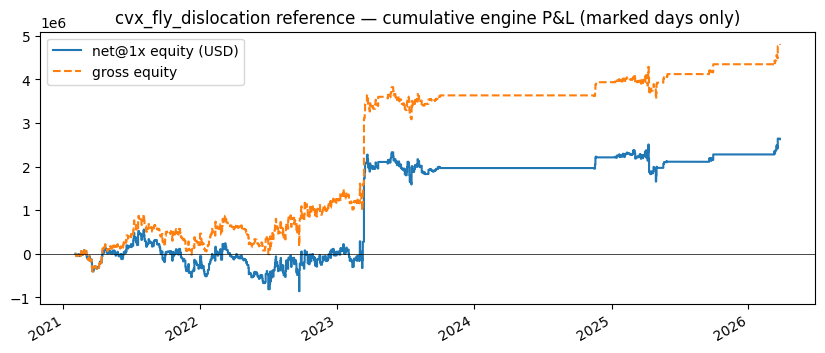

In [7]:
from RVUtils.SFRRVLab.stats import nw_tstat

daily_net = equity.diff()
daily_net.iloc[0] = equity.iloc[0]
fees_by_day = closed.groupby(closed["closed_at"].map(pd.Timestamp))["fee_allocated"].sum()
daily_gross = daily_net.add(fees_by_day.reindex(daily_net.index).fillna(0.0))

def _sr(x: pd.Series) -> float:
    sd = float(x.std(ddof=1))
    return float("nan") if sd == 0 else float(x.mean() / sd * np.sqrt(252.0))

dd = equity - equity.cummax()
print(f"net@1x:  ann. Sharpe (marked days) {_sr(daily_net):+.2f}, "
      f"NW t {nw_tstat(daily_net):+.2f}, maxDD {dd.min():,.0f} USD")
print(f"gross:   ann. Sharpe (marked days) {_sr(daily_gross):+.2f}, "
      f"NW t {nw_tstat(daily_gross):+.2f}")
print("(fee timing: lumps at unwinds — net Sharpe carries the unwind-day spikes)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(equity.index, equity.values, where="post", label="net@1x equity (USD)")
ax.step(equity.index, equity.values + fees_by_day.reindex(equity.index)
        .fillna(0.0).cumsum().values, where="post", ls="--", label="gross equity")
ax.axhline(0, lw=0.5, color="k")
ax.set_title("cvx_fly_dislocation reference — cumulative engine P&L (marked days only)")
ax.legend()
fig.autofmt_xdate()
plt.show()

## 7. Closed-positions log (leg level)

In [8]:
view = closed[["tag", "opened_at", "closed_at", "holding_period_steps",
               "gross_realized_pnl", "fee_allocated", "realized_pnl"]].copy()
print(view.to_string(index=False))
print(f"\nfee_allocated sums to {closed['fee_allocated'].sum():,.0f} USD "
      f"(= {len(priced)} x {FEE_1X:,.0f})")

 tag  opened_at  closed_at  holding_period_steps  gross_realized_pnl  fee_allocated  realized_pnl
fd33 2021-02-02 2021-04-12                    47        1.737468e+06   19166.666667  1.718301e+06
fd33 2021-02-02 2021-04-12                    47       -3.167013e+06   19166.666667 -3.186179e+06
fd33 2021-02-02 2021-04-12                    47        1.531139e+06   19166.666667  1.511972e+06
fd28 2021-02-02 2021-05-03                    62        1.367448e+06   19166.666667  1.348281e+06
fd28 2021-02-02 2021-05-03                    62       -2.739556e+06   19166.666667 -2.758722e+06
fd28 2021-02-02 2021-05-03                    62        1.347215e+06   19166.666667  1.328048e+06
fd25 2021-02-18 2021-05-18                    62        6.518108e+05   19166.666667  6.326442e+05
fd25 2021-02-18 2021-05-18                    62       -1.434458e+06   19166.666667 -1.453624e+06
fd25 2021-02-18 2021-05-18                    62        7.283501e+05   19166.666667  7.091834e+05
 fd3 2021-03-08 2021

## 8. Tearsheet (plain-stats fallback if plotting is unavailable)

In [9]:
try:
    from IPython.display import display

    from BT.query_tearsheet import QueryBacktestTearSheet

    ts = QueryBacktestTearSheet.from_backtest(bt)
    display(ts.plot_plotly())
except Exception as exc:  # noqa: BLE001 — fallback is the contract
    print(f"tearsheet unavailable ({type(exc).__name__}: {exc}); plain stats:")
    print(f"  marks {len(equity)}, net {equity.iloc[-1]:+,.0f} USD, "
          f"gross {gross_total:+,.0f} USD, fees@1x {fee_total_1x:,.0f} USD, "
          f"episodes {len(priced)}, closed legs {len(closed)}, maxDD {dd.min():,.0f} USD")

## 9. DSR at the declared suite config count

`n_trials = 4` — the declared §6 cell count across the whole suite (2
strikeless pairs + 1 harvest + 1 dislocation config). This notebook runs ONE
frozen cell, so there is no cross-trial Sharpe dispersion to measure here;
`sr_variance=None` makes the benchmark `sr0 = 0` and the DSR reduces to
PSR(SR > 0) — the n_trials=4 deflation is therefore NOT active in this
number, and that is printed rather than hidden.

In [10]:
from BT.signals.deflated_sharpe import deflated_sharpe

d = deflated_sharpe(daily_net.to_numpy(dtype=float), n_trials=4, sr_variance=None)
print(f"DSR on daily net P&L: dsr_prob {d['dsr_prob']:.3f}  (sr {d['sr']:+.4f}/day, "
      f"annualised {d['sr_annualised']:+.2f}, sr0 {d['sr0']:.4f} — sr0=0 because a "
      f"single frozen cell has no cross-trial dispersion; DSR here = PSR vs 0)")
print("reference number at the declared config count, not a verdict")

DSR on daily net P&L: dsr_prob 0.845  (sr +0.0344/day, annualised +0.55, sr0 0.0000 — sr0=0 because a single frozen cell has no cross-trial dispersion; DSR here = PSR vs 0)
reference number at the declared config count, not a verdict


## 10. What this run certifies — and does not

Certifies: the frozen §6 dislocation book is expressible in the production
engine — panel gates → episodes with screen-frozen PCA-neutral weights →
real `AddQueryAction`/`UnwindPositionsAction` events on explicit-dated
OUTRIGHT legs, direction re-derived from the engine's ±bpv mirror, no
equity-curve holes, fee totals exactly the known constants. Does NOT certify
a strategy: no aliveness claim, no RV-loop registration, no verdict — and
episode SELECTION rests on the panel's strip-approximation carry (header),
which is a stated convention of the signal layer, not of the P&L.